In [5]:
import sys
import os

sys.path.append(os.path.abspath('../..'))

from technical_func import set_random_seed
from sin_noise_removal import generate_noisy_sine_data
from visual_tools import visualize_sine_manifold
from model_autoencoder import AutoencoderSimple
from train_model import fit_model, get_data_loader
from data_file import TensorIndexDataset
import matplotlib.pyplot as plt
import numpy as np

device = "cuda:0"

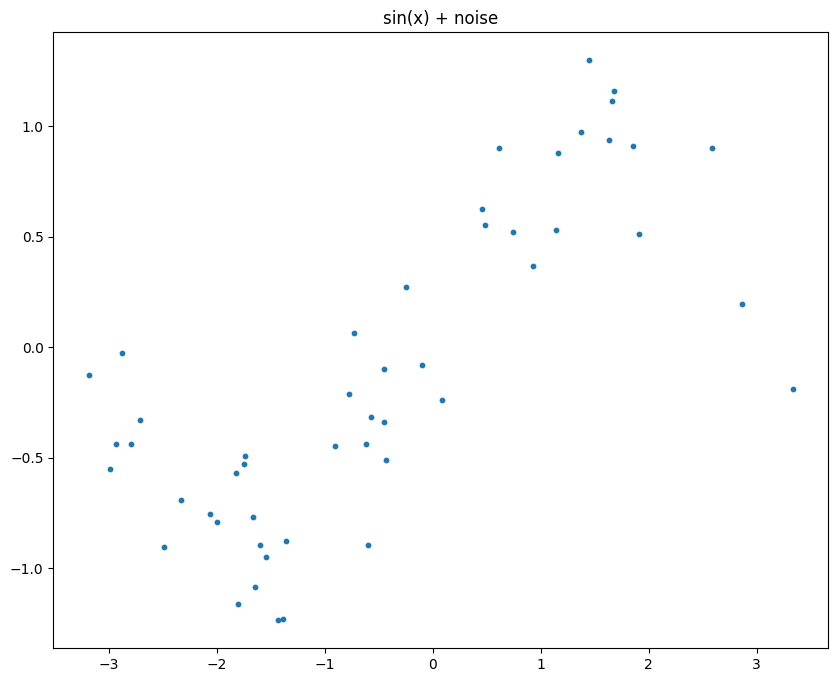

In [6]:
set_random_seed(50)

noisy_points, ground_truth_noise = generate_noisy_sine_data(50, 0.2)
_, ground_truth = generate_noisy_sine_data(10000, 0.0)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
sc = ax.scatter(noisy_points[:, 0], noisy_points[:, 1], s=10)
ax.set_title("sin(x) + noise")
plt.show()


In [7]:
if __name__ ==  "__main__":
    batch_size = 50
    dataset_train = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
    dataset_val = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
    train_loader = get_data_loader(batch_size, dataset_train)
    val_loader = get_data_loader(50, dataset_val, shuffle=False)


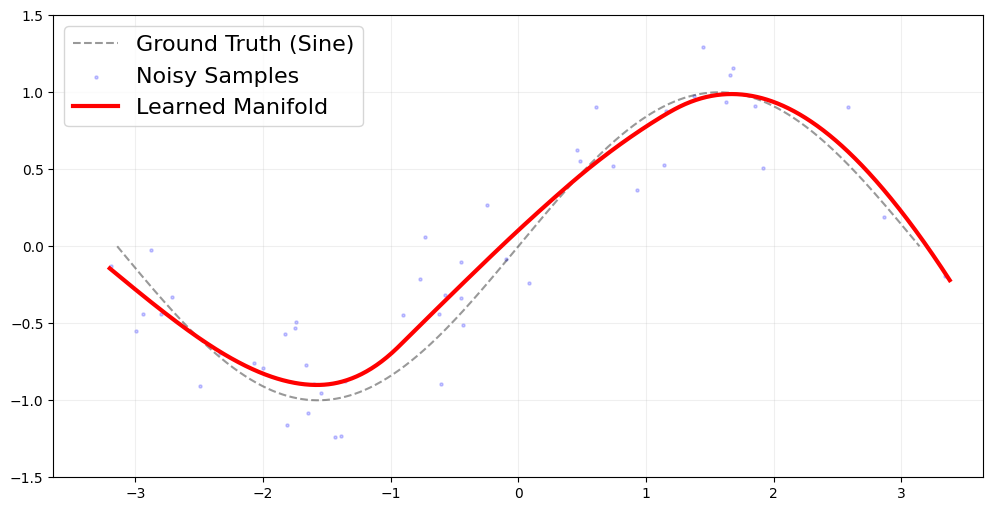

Train metrics: {'loss': 0.024966543540358543, 'rec_loss': 0.02496240846812725, 'enc_loss': 4.13441830460215e-06, 'dec_loss': 0.0} cur epoch: 2000


In [8]:
set_random_seed(50)

student = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
teacher = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
teacher.load_state_dict(student.state_dict())
    
student, teacher, _, _ = fit_model(student, teacher, train_loader, val_loader=val_loader, epochs=2001, reg_mode="encoder", n_points=2, lambda_enc=1,
                                    radius_encoder=0.5, verbose_recon=True, func_recon=visualize_sine_manifold, period=1000)

In [11]:
MY_DPI = 100
BASE_FONT = 20  # Этот шрифт будет эталоном

plt.rcParams.update({
    'font.size': BASE_FONT,
    'figure.dpi': MY_DPI,
    'savefig.dpi': MY_DPI,
    'axes.titlesize': BASE_FONT,
    'legend.fontsize': BASE_FONT
})

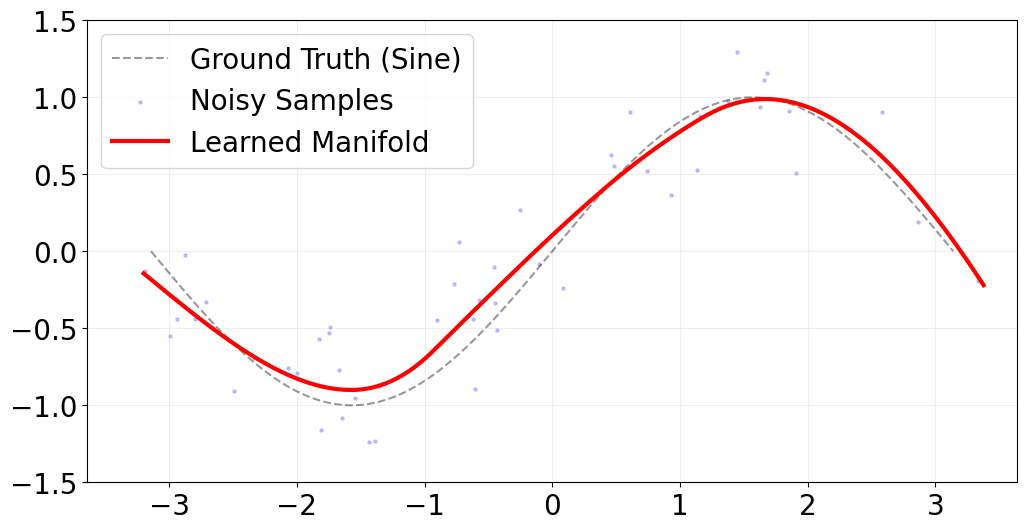

In [12]:
from visual_tools import visualize_sine_manifold
visualize_sine_manifold(student, val_loader)

In [29]:
from sin_noise_removal import evaluate_mse_on_sin



evaluate_mse_on_sin(student) * 100

Test MSE (10k points): 0.005685


0.5684513133019209

In [ ]:
mse_results = []


for seed_ in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    set_random_seed(seed_)
    noisy_points, ground_truth_noise = generate_noisy_sine_data(50, 0.2)
    _, ground_truth = generate_noisy_sine_data(10000, 0.0)
    if __name__ ==  "__main__":
        batch_size = 50
        dataset_train = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
        dataset_val = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
        train_loader = get_data_loader(batch_size, dataset_train)
        val_loader = get_data_loader(50, dataset_val, shuffle=False)

    
    student = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
    teacher = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
    teacher.load_state_dict(student.state_dict())
    
    student, teacher, _, _ = fit_model(student, teacher, train_loader, val_loader=val_loader, epochs=2001, reg_mode="encoder", n_points=2, lambda_enc=1,
                                    radius_encoder=0.5, verbose_recon=False, verbose_latent=False, func_latent=None, func_recon=None, period=2000)
    
    mse_value = evaluate_mse_on_sin(student) * 100
    mse_results.append(mse_value)   
    print(f"Seed: {seed_}, MSE: {mse_value:.6f}")

Train metrics: {'loss': 1.676790714263916, 'rec_loss': 1.676790714263916, 'enc_loss': 3.769680034793055e-08, 'dec_loss': 0.0} cur epoch: 0
Train metrics: {'loss': 0.017500627785921097, 'rec_loss': 0.01750035770237446, 'enc_loss': 2.7017833303943917e-07, 'dec_loss': 0.0} cur epoch: 2000
Test MSE (10k points): 0.006021
Seed: 1, MSE: 0.602116
Train metrics: {'loss': 1.3644657135009766, 'rec_loss': 1.3644657135009766, 'enc_loss': 1.013573438513049e-07, 'dec_loss': 0.0} cur epoch: 0
Train metrics: {'loss': 0.015941619873046875, 'rec_loss': 0.015938838943839073, 'enc_loss': 2.7812300231744302e-06, 'dec_loss': 0.0} cur epoch: 2000
Test MSE (10k points): 0.010376
Seed: 2, MSE: 1.037565
Train metrics: {'loss': 2.2760205268859863, 'rec_loss': 2.2760205268859863, 'enc_loss': 1.78879755452499e-08, 'dec_loss': 0.0} cur epoch: 0
Train metrics: {'loss': 0.025804245844483376, 'rec_loss': 0.025798538699746132, 'enc_loss': 5.706469437427586e-06, 'dec_loss': 0.0} cur epoch: 2000
Test MSE (10k points): 0.

In [ ]:

mse_results.sort()

truncated_results = mse_results[1:-1]

mean_mse = np.mean(truncated_results)
variance_mse = np.var(truncated_results)

print(f"\nИтоговые результаты (без min/max):")
print(f"Среднее MSE: {mean_mse:.6f}")
print(f"Дисперсия MSE: {variance_mse:.6f}")



Итоговые результаты (без min/max):
Среднее MSE: 0.829602
Дисперсия MSE: 0.059940


In [ ]:
mse_results = []
for seed_ in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    set_random_seed(seed_)
    noisy_points, ground_truth_noise = generate_noisy_sine_data(50, 0.2)
    _, ground_truth = generate_noisy_sine_data(10000, 0.0)
    if __name__ ==  "__main__":
        batch_size = 50
        dataset_train = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
        dataset_val = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
        train_loader = get_data_loader(batch_size, dataset_train)
        val_loader = get_data_loader(50, dataset_val, shuffle=False)

    
    student = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
    teacher = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
    teacher.load_state_dict(student.state_dict())
    
    student, teacher, _, _ = fit_model(student, teacher, train_loader, val_loader=val_loader, epochs=2001, reg_mode="decoder", n_points=2, lambda_dec=1,
                                    radius_decoder=0.05, verbose_recon=False, verbose_latent=False, func_latent=None, func_recon=None, period=2000)
    
    mse_value = evaluate_mse_on_sin(student) * 100
    mse_results.append(mse_value)   
    print(f"Seed: {seed_}, MSE: {mse_value:.6f}")

Train metrics: {'loss': 1.6841851472854614, 'rec_loss': 1.676790714263916, 'enc_loss': 0.0, 'dec_loss': 1.4788851737976074} cur epoch: 0
Train metrics: {'loss': 0.02882145158946514, 'rec_loss': 0.017519596964120865, 'enc_loss': 0.0, 'dec_loss': 0.011301854625344276} cur epoch: 2000
Test MSE (10k points): 0.005482
Seed: 1, MSE: 0.548193
Train metrics: {'loss': 1.3711647987365723, 'rec_loss': 1.3644657135009766, 'enc_loss': 0.0, 'dec_loss': 1.3398196697235107} cur epoch: 0
Train metrics: {'loss': 0.026267336681485176, 'rec_loss': 0.01567038707435131, 'enc_loss': 0.0, 'dec_loss': 0.010596949607133865} cur epoch: 2000
Test MSE (10k points): 0.009809
Seed: 2, MSE: 0.980943
Train metrics: {'loss': 2.286095380783081, 'rec_loss': 2.2760205268859863, 'enc_loss': 0.0, 'dec_loss': 2.014986276626587} cur epoch: 0
Train metrics: {'loss': 0.04009125754237175, 'rec_loss': 0.024694452062249184, 'enc_loss': 0.0, 'dec_loss': 0.01539680641144514} cur epoch: 2000
Test MSE (10k points): 0.010547
Seed: 3, M

In [17]:
mse_results.sort()

truncated_results = mse_results[1:-1]

mean_mse = np.mean(truncated_results)
variance_mse = np.var(truncated_results)

print(f"\nИтоговые результаты (без min/max):")
print(f"Среднее MSE: {mean_mse:.6f}")
print(f"Дисперсия MSE: {variance_mse:.6f}")



Итоговые результаты (без min/max):
Среднее MSE: 0.857623
Дисперсия MSE: 0.061341


In [ ]:
mse_results = []
rads = [0.5]
for r_ in rads:
    for seed_ in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
        set_random_seed(seed_)
        noisy_points, ground_truth_noise = generate_noisy_sine_data(50, 0.2)
        _, ground_truth = generate_noisy_sine_data(10000, 0.0)
        if __name__ ==  "__main__":
            batch_size = 50
            dataset_train = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
            dataset_val = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
            train_loader = get_data_loader(batch_size, dataset_train)
            val_loader = get_data_loader(50, dataset_val, shuffle=False)

        
        student = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
        teacher = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
        teacher.load_state_dict(student.state_dict())
        
        student, teacher, _, _ = fit_model(student, teacher, train_loader, val_loader=val_loader, epochs=2001, reg_mode="encoder", n_points=2, lambda_enc=1,
                                        radius_encoder=4, verbose_recon=False, verbose_latent=False, func_latent=None, func_recon=None, period=2000)
        
        mse_value = evaluate_mse_on_sin(student) * 100
        mse_results.append(mse_value)   
        print(f"Seed: {seed_}, MSE: {mse_value:.6f}")

Train metrics: {'loss': 1.6767908334732056, 'rec_loss': 1.676790714263916, 'enc_loss': 1.4156637917039916e-05, 'dec_loss': 0.0} cur epoch: 0
Train metrics: {'loss': 0.017419101670384407, 'rec_loss': 0.017383718863129616, 'enc_loss': 3.538269083946943e-05, 'dec_loss': 0.0} cur epoch: 2000
Test MSE (10k points): 0.005886
Seed: 1, MSE: 0.588581
Train metrics: {'loss': 1.3644661903381348, 'rec_loss': 1.3644657135009766, 'enc_loss': 8.51189688546583e-05, 'dec_loss': 0.0} cur epoch: 0
Train metrics: {'loss': 0.01719639077782631, 'rec_loss': 0.0165876317769289, 'enc_loss': 0.0006087598158046603, 'dec_loss': 0.0} cur epoch: 2000
Test MSE (10k points): 0.007830
Seed: 2, MSE: 0.783006
Train metrics: {'loss': 2.2760205268859863, 'rec_loss': 2.2760205268859863, 'enc_loss': 2.0483953449002e-06, 'dec_loss': 0.0} cur epoch: 0
Train metrics: {'loss': 0.02690676972270012, 'rec_loss': 0.025375334545969963, 'enc_loss': 0.0015314356423914433, 'dec_loss': 0.0} cur epoch: 2000
Test MSE (10k points): 0.01142

In [19]:
mse_results.sort()

truncated_results = mse_results[1:-1]

mean_mse = np.mean(truncated_results)
variance_mse = np.var(truncated_results)

print(f"\nИтоговые результаты (без min/max):")
print(f"Среднее MSE: {mean_mse:.6f}")
print(f"Дисперсия MSE: {variance_mse:.6f}")



Итоговые результаты (без min/max):
Среднее MSE: 0.848774
Дисперсия MSE: 0.086609


In [21]:
mse_results = []
rads = [0.5]
for r_ in rads:
    for seed_ in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
        set_random_seed(seed_)
        noisy_points, ground_truth_noise = generate_noisy_sine_data(50, 0.2)
        _, ground_truth = generate_noisy_sine_data(10000, 0.0)
        if __name__ ==  "__main__":
            batch_size = 50
            dataset_train = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
            dataset_val = TensorIndexDataset(noisy_points, noisy_points.clone(), np.arange(len(noisy_points)))
            train_loader = get_data_loader(batch_size, dataset_train)
            val_loader = get_data_loader(50, dataset_val, shuffle=False)

        
        student = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
        teacher = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
        teacher.load_state_dict(student.state_dict())
        
        student, teacher, _, _ = fit_model(student, teacher, train_loader, val_loader=val_loader, epochs=2001, reg_mode="decoder", n_points=2, lambda_dec=1,
                                        radius_decoder=20, verbose_recon=False, verbose_latent=False, func_latent=None, func_recon=None, period=2000)
        
        mse_value = evaluate_mse_on_sin(student) * 100
        mse_results.append(mse_value)   
        print(f"Seed: {seed_}, MSE: {mse_value:.6f}")

Train metrics: {'loss': 1.6836708784103394, 'rec_loss': 1.676790714263916, 'enc_loss': 0.0, 'dec_loss': 1.376029372215271} cur epoch: 0
Train metrics: {'loss': 0.05050285905599594, 'rec_loss': 0.020697401836514473, 'enc_loss': 0.0, 'dec_loss': 0.029805459082126617} cur epoch: 2000
Test MSE (10k points): 0.014418
Seed: 1, MSE: 1.441783
Train metrics: {'loss': 1.3685767650604248, 'rec_loss': 1.3644657135009766, 'enc_loss': 0.0, 'dec_loss': 0.8222142457962036} cur epoch: 0
Train metrics: {'loss': 0.06525411456823349, 'rec_loss': 0.02241137996315956, 'enc_loss': 0.0, 'dec_loss': 0.04284273460507393} cur epoch: 2000
Test MSE (10k points): 0.012059
Seed: 2, MSE: 1.205933
Train metrics: {'loss': 2.2859292030334473, 'rec_loss': 2.2760205268859863, 'enc_loss': 0.0, 'dec_loss': 1.9817392826080322} cur epoch: 0
Train metrics: {'loss': 0.09110109508037567, 'rec_loss': 0.032964885234832764, 'enc_loss': 0.0, 'dec_loss': 0.05813620612025261} cur epoch: 2000
Test MSE (10k points): 0.015182
Seed: 3, MS

In [23]:
mse_results.sort()

truncated_results = mse_results[1:-1]

mean_mse = np.mean(truncated_results)
variance_mse = np.var(truncated_results)

print(f"\nИтоговые результаты (без min/max):")
print(f"Среднее MSE: {mean_mse:.6f}")
print(f"Дисперсия MSE: {variance_mse:.6f}")



Итоговые результаты (без min/max):
Среднее MSE: 1.648692
Дисперсия MSE: 0.215541
